# Predicción de los Efectos de la Música en la Salud Mental:
**Sebastián Forero Duque y Santiago Gallego Henao**
1. Preparación de Datos
2. División cruzada
3. Aprendizaje del Modelo y evaluación:
    
    cv=10

    cross_validate(model, X, Y, cv=cv, scoring=('neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error'), return_train_score=True)

    Nota: las métricas deben multiplicarse por -1 porque scikit-learn asume que "más grande es mejor"
4. Selección del modelo
5. Guardamos el modelo

In [ ]:
# Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

#Convertir Arff a CSV

1.   Elemento de la lista
2.   Elemento de la lista



In [ ]:
from scipy.io import arff
import pandas as pd

def arff_a_csv():
    archivo_arff = r'PrediccionMussicEfLimpios.arff'
    archivo_csv = 'PrediccionMussicEfLimpios.csv'

    data, meta = arff.loadarff(archivo_arff)
    df = pd.DataFrame(data)

    # Decodifica columnas tipo bytes (strings/nominales)
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')

    df.to_csv(archivo_csv, index=False, encoding='utf-8-sig')

# Ejecutar
arff_a_csv()



In [ ]:
# Cargamos los datos
data = pd.read_csv("PrediccionMussicEfLimpios.csv")
data.head()

,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Frequency [Classical],Frequency [Country],...,Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,OCD,Music effects
0,35.0,Spotify,3.0,No,Yes,No,Folk,Yes,Sometimes,Sometimes,...,Never,Rarely,Never,Never,Sometimes,Sometimes,8.0,2.0,8.0,No effect
1,28.0,Spotify,3.0,No,Yes,Yes,Metal,Yes,Very frequently,Never,...,Very frequently,Rarely,Sometimes,Never,Very frequently,Very frequently,8.0,8.0,2.0,Improve
2,30.0,I do not use a streaming service.,0.0,No,No,No,Metal,No,Rarely,Never,...,Sometimes,Never,Never,Rarely,Rarely,Rarely,10.0,10.0,9.0,Improve
3,73.0,Pandora,3.0,Yes,No,No,R&B,Yes,Sometimes,Very frequently,...,Rarely,Sometimes,Very frequently,Sometimes,Sometimes,Never,5.0,4.0,1.0,Improve
4,68.0,Pandora,1.0,Yes,No,No,Gospel,No,Very frequently,Never,...,Never,Never,Never,Never,Never,Never,10.0,10.0,0.0,Improve


In [ ]:
# Convertimos las OBJECT a category
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age                           728 non-null    float64 
 1   Primary streaming service     728 non-null    category
 2   Hours per day                 728 non-null    float64 
 3   While working                 728 non-null    category
 4   Instrumentalist               728 non-null    category
 5   Composer                      728 non-null    category
 6   Fav genre                     728 non-null    category
 7   Exploratory                   728 non-null    category
 8   Frequency [Classical]         728 non-null    category
 9   Frequency [Country]           728 non-null    category
 10  Frequency [EDM]               728 non-null    category
 11  Frequency [Folk]              728 non-null    category
 12  Frequency [Gospel]            728 non-null    cate

<Axes: >

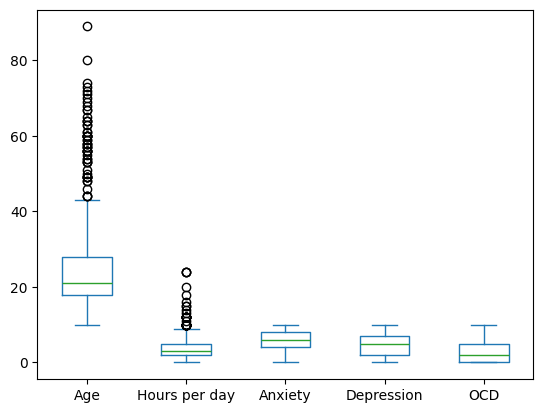

In [ ]:
data.plot(kind='box')

In [ ]:
data.describe()

,Age,Hours per day,Anxiety,Depression,OCD
count,728.000000,728.000000,728.000000,728.000000,728.000000
mean,25.143054,3.591415,5.849588,4.803571,2.645604
std,11.919787,3.038554,2.787469,3.024069,2.844204
min,10.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,4.000000,2.000000,0.000000
50%,21.000000,3.000000,6.000000,5.000000,2.000000
75%,28.000000,5.000000,8.000000,7.000000,5.000000
max,89.000000,24.000000,10.000000,10.000000,10.000000


In [ ]:
# Instalar pandas profiling
!pip install -q ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Cargar librería para Profiling
from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=False) # minimal=True para no hacer completo
profile_data

# Guardamos en html el perfilado de datos
profile_data.to_file(output_file="MusicReport.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 28/28 [00:01<00:00, 22.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

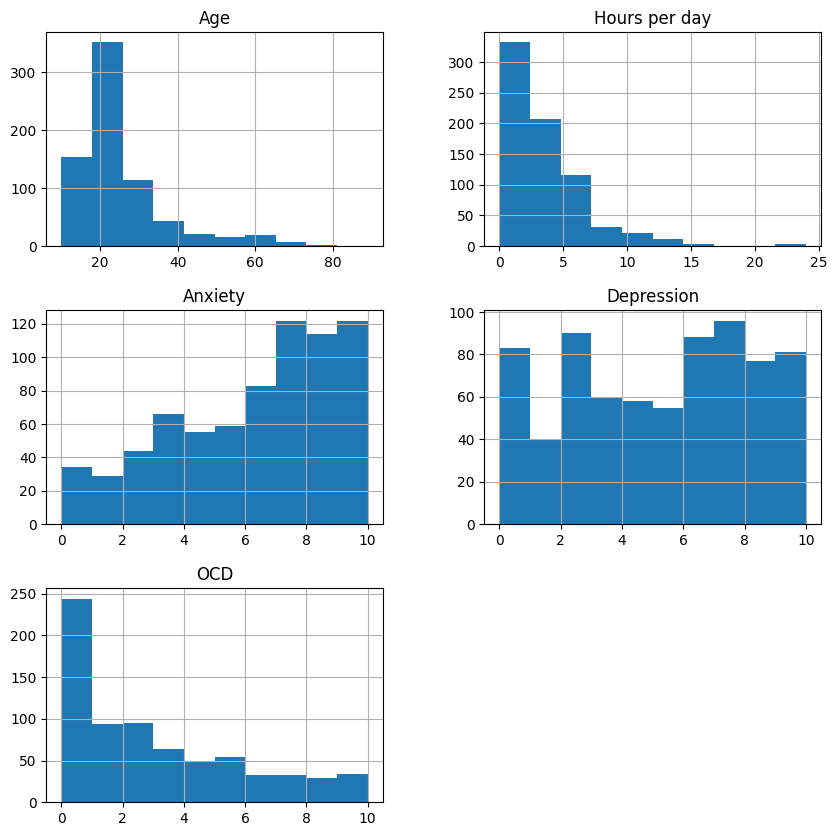

In [ ]:
# Graficar las variables:
data.hist(figsize=(10,10))
plt.show()

<Axes: ylabel='Frequency'>

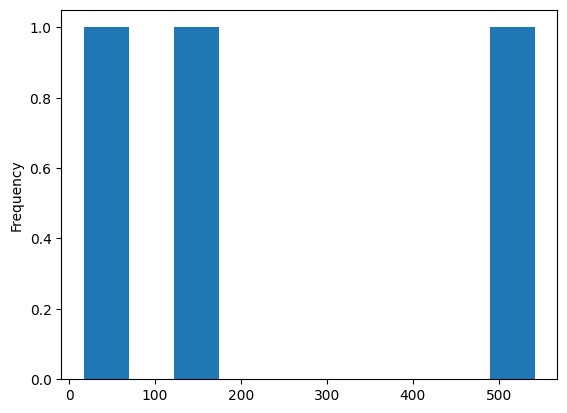

In [ ]:
data['Music effects'].value_counts().plot(kind='hist')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age                           728 non-null    float64 
 1   Primary streaming service     728 non-null    category
 2   Hours per day                 728 non-null    float64 
 3   While working                 728 non-null    category
 4   Instrumentalist               728 non-null    category
 5   Composer                      728 non-null    category
 6   Fav genre                     728 non-null    category
 7   Exploratory                   728 non-null    category
 8   Frequency [Classical]         728 non-null    category
 9   Frequency [Country]           728 non-null    category
 10  Frequency [EDM]               728 non-null    category
 11  Frequency [Folk]              728 non-null    category
 12  Frequency [Gospel]            728 non-null    cate

#Modificacion:
Debido al bajo número de observaciones de la clase worsen, se recodificó la variable objetivo en dos categorías: effect y no effect, agrupando worsen con no effect. Esta transformación permite reducir el problema a una clasificación binaria más estable y con mejor capacidad de generalización, enfocando el modelo en predecir si la música genera un efecto positivo o no en el oyente.

In [ ]:
data["Music effects"] = data["Music effects"].replace({
    "Worsen": "No effect"
})

/tmp/ipykernel_53736/2983309074.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data["Music effects"] = data["Music effects"].replace({


<Axes: ylabel='Frequency'>

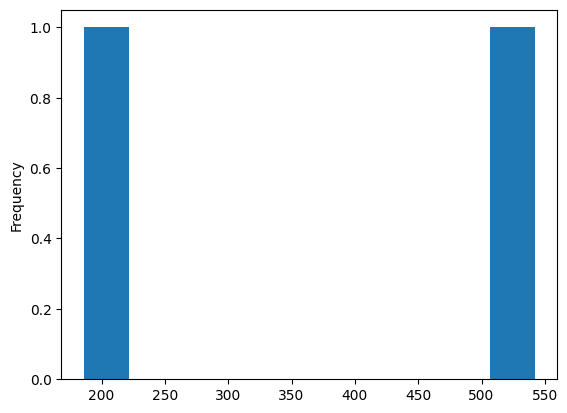

In [ ]:
data['Music effects'].value_counts().plot(kind='hist')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age                           728 non-null    float64 
 1   Primary streaming service     728 non-null    category
 2   Hours per day                 728 non-null    float64 
 3   While working                 728 non-null    category
 4   Instrumentalist               728 non-null    category
 5   Composer                      728 non-null    category
 6   Fav genre                     728 non-null    category
 7   Exploratory                   728 non-null    category
 8   Frequency [Classical]         728 non-null    category
 9   Frequency [Country]           728 non-null    category
 10  Frequency [EDM]               728 non-null    category
 11  Frequency [Folk]              728 non-null    category
 12  Frequency [Gospel]            728 non-null    cate

<Axes: xlabel='Music effects'>

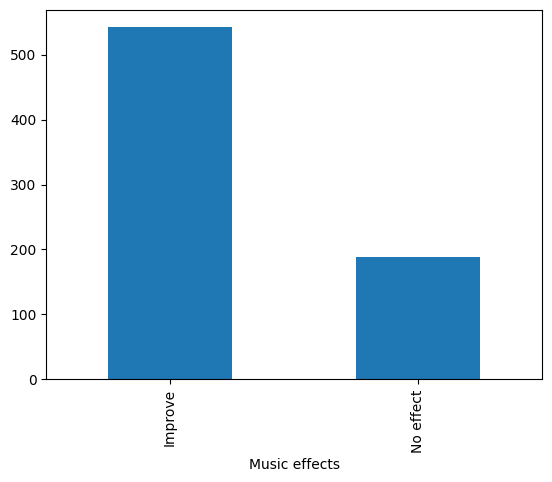

In [ ]:
# BALANCEO
# La clase minoritaria tendrá el 35% del tamaño de la clase mayoritaria

from imblearn.over_sampling import SMOTE, SMOTENC



X = data.drop("Music effects", axis = 1)

Y = data['Music effects']

# Sacar nombres de columnas categóricas
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Sacar índices de esas columnas
cat_idx = [X.columns.get_loc(col) for col in cat_cols]

#Categorical features es para decirle cuales son las variables categoricas (el indice que sale en data.info)
smote = SMOTENC(k_neighbors=2, categorical_features=cat_idx, sampling_strategy=0.35)

X_smote, y_smote = smote.fit_resample(X,Y)



# Creamos un dataframe con los resultados (X_smote, y_smote)

data  = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)

data['Music effects']=y_smote

data['Music effects'].value_counts().plot(kind='bar')


In [ ]:

target_col = 'Music effects'

# 1. Identificar todas las columnas categóricas

cat_cols = data.drop(columns=[target_col]).select_dtypes(include=['category', 'object']).columns.tolist()

# 2. Separarlas por cantidad de categorías únicas
binarias = [col for col in cat_cols if data[col].nunique() == 2]
multi_nivel = [col for col in cat_cols if data[col].nunique() > 2]
print(f'Categorías binarias: {binarias}')
print(f'Categorías multi-nivel: {multi_nivel}')

# 3. Aplicar get_dummies por separado
# Primero para las binarias con drop_first=True
if binarias:
    data = pd.get_dummies(data, columns=binarias, drop_first=True, dtype=int)

# Luego para las de más de 2 categorías con drop_first=False
if multi_nivel:
    data = pd.get_dummies(data, columns=multi_nivel, drop_first=False, dtype=int)

data.head()

Categorías binarias: ['While working', 'Instrumentalist', 'Composer', 'Exploratory']
Categorías multi-nivel: ['Primary streaming service', 'Fav genre', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]']


,Age,Hours per day,Anxiety,Depression,OCD,Music effects,While working_Yes,Instrumentalist_Yes,Composer_Yes,Exploratory_Yes,...,Frequency [Rap]_Sometimes,Frequency [Rap]_Very frequently,Frequency [Rock]_Never,Frequency [Rock]_Rarely,Frequency [Rock]_Sometimes,Frequency [Rock]_Very frequently,Frequency [Video game music]_Never,Frequency [Video game music]_Rarely,Frequency [Video game music]_Sometimes,Frequency [Video game music]_Very frequently
0,35.0,3.0,8.0,2.0,8.0,No effect,0,1,0,1,...,0,0,0,0,1,0,0,0,1,0
1,28.0,3.0,8.0,8.0,2.0,Improve,0,1,1,1,...,0,0,0,0,0,1,0,0,0,1
2,30.0,0.0,10.0,10.0,9.0,Improve,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,73.0,3.0,5.0,4.0,1.0,Improve,1,0,0,1,...,1,0,0,0,1,0,1,0,0,0
4,68.0,1.0,10.0,10.0,0.0,Improve,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
# LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["Music effects"]=labelencoder.fit_transform(data["Music effects"])
data.head()

,Age,Hours per day,Anxiety,Depression,OCD,Music effects,While working_Yes,Instrumentalist_Yes,Composer_Yes,Exploratory_Yes,...,Frequency [Rap]_Sometimes,Frequency [Rap]_Very frequently,Frequency [Rock]_Never,Frequency [Rock]_Rarely,Frequency [Rock]_Sometimes,Frequency [Rock]_Very frequently,Frequency [Video game music]_Never,Frequency [Video game music]_Rarely,Frequency [Video game music]_Sometimes,Frequency [Video game music]_Very frequently
0,35.0,3.0,8.0,2.0,8.0,1,0,1,0,1,...,0,0,0,0,1,0,0,0,1,0
1,28.0,3.0,8.0,8.0,2.0,0,0,1,1,1,...,0,0,0,0,0,1,0,0,0,1
2,30.0,0.0,10.0,10.0,9.0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,73.0,3.0,5.0,4.0,1.0,0,1,0,0,1,...,1,0,0,0,1,0,1,0,0,0
4,68.0,1.0,10.0,10.0,0.0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
# Configuración de variables
objetivo='Music effects'
predictoras_numericas=['Age','Hours per day', 'Anxiety', 'Depression', 'OCD']
predictoras_categoricas_2cat=['While working', 'Instrumentalist', 'Composer', 'Exploratory']
predictoras_categoricas_multicat=['Primary streaming service', 'Fav genre', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]']

In [ ]:
# Validación Cruzada
from sklearn.model_selection import cross_validate

# Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()

# Medidas de evaluación
scoring=('neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error')

# Muestreo lineal
cv=10

In [ ]:
# Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 95 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Age                                                          731 non-null    float64
 1   Hours per day                                                731 non-null    float64
 2   Anxiety                                                      731 non-null    float64
 3   Depression                                                   731 non-null    float64
 4   OCD                                                          731 non-null    float64
 5   While working_Yes                                            731 non-null    int64  
 6   Instrumentalist_Yes                                          731 non-null    int64  
 7   Composer_Yes                                                 731 non-null    int

In [ ]:
# Tree
from sklearn import tree
modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=7, max_depth=None)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.031358,0.015656,-0.330907,-0.228352,-0.228785,-0.114176,-0.478315,-0.337900,-7.730689e+14,-5.142037e+14
1,0.014076,0.007622,-0.352631,-0.208571,-0.247905,-0.104285,-0.497900,-0.322933,-8.387321e+14,-4.696597e+14
2,0.013901,0.007948,-0.326737,-0.207113,-0.207347,-0.103557,-0.455353,-0.321802,-9.895027e+14,-4.663774e+14
3,0.014619,0.007464,-0.314044,-0.204470,-0.222112,-0.102235,-0.471288,-0.319742,-6.404915e+14,-4.604265e+14
4,0.014212,0.007518,-0.369667,-0.202116,-0.271205,-0.101058,-0.520774,-0.317897,-6.221924e+14,-4.551257e+14
5,0.013957,0.007709,-0.418482,-0.217228,-0.312663,-0.108614,-0.559163,-0.329567,-8.849275e+14,-4.891544e+14
6,0.014848,0.007024,-0.382748,-0.209839,-0.273931,-0.104919,-0.523384,-0.323913,-1.146605e+15,-4.725154e+14
7,0.014357,0.008502,-0.406017,-0.206085,-0.297771,-0.103042,-0.545684,-0.321002,-9.287600e+14,-4.640613e+14
8,0.013618,0.007496,-0.326509,-0.205651,-0.232220,-0.102825,-0.481892,-0.320664,-5.684959e+14,-4.630840e+14
9,0.013297,0.007367,-0.401126,-0.228515,-0.273258,-0.114258,-0.522740,-0.338020,-8.263956e+14,-5.145711e+14


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

# Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,1.582410e-02
score_time,8.430386e-03
test_neg_mean_absolute_error,-3.628868e-01
train_neg_mean_absolute_error,-2.117941e-01
test_neg_mean_squared_error,-2.567197e-01
train_neg_mean_squared_error,-1.058971e-01
test_neg_root_mean_squared_error,-5.056494e-01
train_neg_root_mean_squared_error,-3.253439e-01
test_neg_mean_absolute_percentage_error,-8.219171e+14
train_neg_mean_absolute_percentage_error,-4.769179e+14


In [ ]:
# Se almacena en el df la medida a comparar
import pandas as pd
comparacion_CV['Tree']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree
0,-0.256757
1,-0.260274
2,-0.260274
3,-0.260274
4,-0.260274
5,-0.260274
6,-0.260274
7,-0.260274
8,-0.260274
9,-0.246575


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.9, criterion='gini',
                              max_depth=20, min_samples_leaf=10)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.398507,0.023838,-0.256757,-0.258752,-0.256757,-0.258752,-0.506712,-0.508677,-0.256757,-0.258752
1,0.395266,0.020071,-0.260274,-0.256839,-0.260274,-0.256839,-0.510171,-0.506793,-0.260274,-0.256839
2,0.400693,0.020549,-0.260274,-0.253799,-0.260274,-0.253799,-0.510171,-0.503785,-0.260274,-0.253799
3,0.384925,0.018452,-0.260274,-0.258359,-0.260274,-0.258359,-0.510171,-0.508290,-0.260274,-0.258359
4,0.379977,0.032549,-0.260274,-0.258359,-0.260274,-0.258359,-0.510171,-0.508290,-0.260274,-0.258359
5,0.401548,0.019121,-0.260274,-0.249240,-0.260274,-0.249240,-0.510171,-0.499240,-0.260274,-0.249240
6,0.357377,0.018059,-0.260274,-0.255319,-0.260274,-0.255319,-0.510171,-0.505291,-0.260274,-0.255319
7,0.384212,0.040078,-0.260274,-0.258359,-0.260274,-0.258359,-0.510171,-0.508290,-0.260274,-0.258359
8,0.384352,0.018115,-0.260274,-0.258359,-0.260274,-0.258359,-0.510171,-0.508290,-0.260274,-0.258359
9,0.362783,0.017985,-0.246575,-0.258359,-0.246575,-0.258359,-0.496564,-0.508290,-0.246575,-0.258359


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.384964
score_time,0.022882
test_neg_mean_absolute_error,-0.258552
train_neg_mean_absolute_error,-0.256574
test_neg_mean_squared_error,-0.258552
train_neg_mean_squared_error,-0.256574
test_neg_root_mean_squared_error,-0.508464
train_neg_root_mean_squared_error,-0.506523
test_neg_mean_absolute_percentage_error,-0.258552
train_neg_mean_absolute_percentage_error,-0.256574


In [ ]:
# Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF
0,-0.256757,-0.256757
1,-0.260274,-0.260274
2,-0.260274,-0.260274
3,-0.260274,-0.260274
4,-0.260274,-0.260274
5,-0.260274,-0.260274
6,-0.260274,-0.260274
7,-0.260274,-0.260274
8,-0.260274,-0.260274
9,-0.246575,-0.246575


In [ ]:
# KNN
# Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(X[predictoras_numericas]) # Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas]) #70%
X.head()

,Age,Hours per day,Anxiety,Depression,OCD,While working_Yes,Instrumentalist_Yes,Composer_Yes,Exploratory_Yes,Primary streaming service_Apple Music,...,Frequency [Rap]_Sometimes,Frequency [Rap]_Very frequently,Frequency [Rock]_Never,Frequency [Rock]_Rarely,Frequency [Rock]_Sometimes,Frequency [Rock]_Very frequently,Frequency [Video game music]_Never,Frequency [Video game music]_Rarely,Frequency [Video game music]_Sometimes,Frequency [Video game music]_Very frequently
0,0.316456,0.125000,0.8,0.2,0.8,0,1,0,1,0,...,0,0,0,0,1,0,0,0,1,0
1,0.227848,0.125000,0.8,0.8,0.2,0,1,1,1,0,...,0,0,0,0,0,1,0,0,0,1
2,0.253165,0.000000,1.0,1.0,0.9,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,0.797468,0.125000,0.5,0.4,0.1,1,0,0,1,0,...,1,0,0,0,1,0,1,0,0,0
4,0.734177,0.041667,1.0,1.0,0.0,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
# Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')


scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.006181,0.017628,-0.324324,-0.197869,-0.324324,-0.197869,-0.569495,-0.444825,-4.868756e+14,-2.673370e+14
1,0.004386,0.008482,-0.328767,-0.180851,-0.328767,-0.180851,-0.573382,-0.425266,-3.084657e+14,-1.779538e+14
2,0.004353,0.006973,-0.410959,-0.186930,-0.410959,-0.186930,-0.641061,-0.432354,-7.403177e+14,-1.984869e+14
3,0.005080,0.006935,-0.287671,-0.200608,-0.287671,-0.200608,-0.536350,-0.447893,-3.701589e+14,-2.327088e+14
4,0.004467,0.006864,-0.301370,-0.197568,-0.301370,-0.197568,-0.548972,-0.444487,-5.552383e+14,-2.258644e+14
5,0.004280,0.006786,-0.424658,-0.189970,-0.424658,-0.189970,-0.651658,-0.435855,-8.637040e+14,-2.121757e+14
6,0.004157,0.006471,-0.315068,-0.183891,-0.315068,-0.183891,-0.561310,-0.428825,-4.318520e+14,-2.121757e+14
7,0.004175,0.007311,-0.315068,-0.202128,-0.315068,-0.202128,-0.561310,-0.449586,-4.318520e+14,-2.395532e+14
8,0.004151,0.006412,-0.287671,-0.205167,-0.287671,-0.205167,-0.536350,-0.452954,-3.701589e+14,-2.463975e+14
9,0.004889,0.008795,-0.301370,-0.191489,-0.301370,-0.191489,-0.548972,-0.437595,-4.935452e+14,-1.847982e+14


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,4.611778e-03
score_time,8.265710e-03
test_neg_mean_absolute_error,-3.296927e-01
train_neg_mean_absolute_error,-1.936471e-01
test_neg_mean_squared_error,-3.296927e-01
train_neg_mean_squared_error,-1.936471e-01
test_neg_root_mean_squared_error,-5.728858e-01
train_neg_root_mean_squared_error,-4.399639e-01
test_neg_mean_absolute_percentage_error,-5.052168e+14
train_neg_mean_absolute_percentage_error,-2.197451e+14


In [ ]:
# Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,Knn
0,-0.256757,-0.256757,-0.324324
1,-0.260274,-0.260274,-0.328767
2,-0.260274,-0.260274,-0.410959
3,-0.260274,-0.260274,-0.287671
4,-0.260274,-0.260274,-0.301370
5,-0.260274,-0.260274,-0.424658
6,-0.260274,-0.260274,-0.315068
7,-0.260274,-0.260274,-0.315068
8,-0.260274,-0.260274,-0.287671
9,-0.246575,-0.246575,-0.301370


In [ ]:
# Red neuronal

# Solo se configura capas ocultas, no se configura capa de entrada y de salida
# activation -> función activación de la oculta: tanh, logistic, linear, relu
# hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
# learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
# learning_rate_init-> valor tasa de aprendizaje
# momentum-> valor momentum
# max_iter-> iteaciones
# random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)


scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.789242,0.006824,-0.337838,-0.0,-0.337838,-0.0,-0.581238,-0.0,-4.868756e+14,-0.0
1,0.699031,0.006849,-0.342466,-0.0,-0.342466,-0.0,-0.585206,-0.0,-6.786246e+14,-0.0
2,0.776852,0.007644,-0.369863,-0.0,-0.369863,-0.0,-0.608164,-0.0,-5.552383e+14,-0.0
3,0.707193,0.006663,-0.273973,-0.0,-0.273973,-0.0,-0.523424,-0.0,-3.701589e+14,-0.0
4,0.774256,0.006635,-0.342466,-0.0,-0.342466,-0.0,-0.585206,-0.0,-7.403177e+14,-0.0
5,0.742048,0.006634,-0.369863,-0.0,-0.369863,-0.0,-0.608164,-0.0,-7.403177e+14,-0.0
6,0.802704,0.007727,-0.438356,-0.0,-0.438356,-0.0,-0.662085,-0.0,-1.172170e+15,-0.0
7,0.812184,0.006625,-0.315068,-0.0,-0.315068,-0.0,-0.561310,-0.0,-6.786246e+14,-0.0
8,3.240211,0.011509,-0.315068,-0.0,-0.315068,-0.0,-0.561310,-0.0,-6.169315e+14,-0.0
9,1.284657,0.007375,-0.369863,-0.0,-0.369863,-0.0,-0.608164,-0.0,-8.020109e+14,-0.0


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,1.062838e+00
score_time,7.448602e-03
test_neg_mean_absolute_error,-3.474824e-01
train_neg_mean_absolute_error,0.000000e+00
test_neg_mean_squared_error,-3.474824e-01
train_neg_mean_squared_error,0.000000e+00
test_neg_root_mean_squared_error,-5.884268e-01
train_neg_root_mean_squared_error,0.000000e+00
test_neg_mean_absolute_percentage_error,-6.841270e+14
train_neg_mean_absolute_percentage_error,0.000000e+00


In [ ]:
# Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,Knn,NN
0,-0.256757,-0.256757,-0.324324,-0.337838
1,-0.260274,-0.260274,-0.328767,-0.342466
2,-0.260274,-0.260274,-0.410959,-0.369863
3,-0.260274,-0.260274,-0.287671,-0.273973
4,-0.260274,-0.260274,-0.301370,-0.342466
5,-0.260274,-0.260274,-0.424658,-0.369863
6,-0.260274,-0.260274,-0.315068,-0.438356
7,-0.260274,-0.260274,-0.315068,-0.315068
8,-0.260274,-0.260274,-0.287671,-0.315068
9,-0.246575,-0.246575,-0.301370,-0.369863


In [ ]:
# SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='rbf', C=5)

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) # Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.044263,0.010228,-0.297297,-0.006088,-0.297297,-0.006088,-0.545250,-0.078027,-3.042973e+14,-0.006088
1,0.042326,0.009278,-0.369863,-0.003040,-0.369863,-0.003040,-0.608164,-0.055132,-5.552383e+14,-0.003040
2,0.041889,0.009180,-0.369863,-0.001520,-0.369863,-0.001520,-0.608164,-0.038984,-5.552383e+14,-0.001520
3,0.072700,0.016150,-0.287671,-0.003040,-0.287671,-0.003040,-0.536350,-0.055132,-3.084657e+14,-0.003040
4,0.064846,0.015378,-0.301370,-0.004559,-0.301370,-0.004559,-0.548972,-0.067522,-5.552383e+14,-0.004559
5,0.066706,0.015278,-0.356164,-0.004559,-0.356164,-0.004559,-0.596795,-0.067522,-6.169315e+14,-0.004559
6,0.176165,0.032440,-0.369863,-0.004559,-0.369863,-0.004559,-0.608164,-0.067522,-6.786246e+14,-0.004559
7,0.143401,0.039581,-0.301370,-0.003040,-0.301370,-0.003040,-0.548972,-0.055132,-4.318520e+14,-0.003040
8,0.154892,0.035239,-0.315068,-0.007599,-0.315068,-0.007599,-0.561310,-0.087171,-4.935452e+14,-0.007599
9,0.155391,0.036393,-0.356164,-0.003040,-0.356164,-0.003040,-0.596795,-0.055132,-7.403177e+14,-0.003040


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,9.625790e-02
score_time,2.191441e-02
test_neg_mean_absolute_error,-3.324695e-01
train_neg_mean_absolute_error,-4.104269e-03
test_neg_mean_squared_error,-3.324695e-01
train_neg_mean_squared_error,-4.104269e-03
test_neg_root_mean_squared_error,-5.758934e-01
train_neg_root_mean_squared_error,-6.272767e-02
test_neg_mean_absolute_percentage_error,-5.239749e+14
train_neg_mean_absolute_percentage_error,-4.104269e-03


In [ ]:
# Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,-0.256757,-0.256757,-0.324324,-0.337838,-0.297297
1,-0.260274,-0.260274,-0.328767,-0.342466,-0.369863
2,-0.260274,-0.260274,-0.410959,-0.369863,-0.369863
3,-0.260274,-0.260274,-0.287671,-0.273973,-0.287671
4,-0.260274,-0.260274,-0.301370,-0.342466,-0.301370
5,-0.260274,-0.260274,-0.424658,-0.369863,-0.356164
6,-0.260274,-0.260274,-0.315068,-0.438356,-0.369863
7,-0.260274,-0.260274,-0.315068,-0.315068,-0.301370
8,-0.260274,-0.260274,-0.287671,-0.315068,-0.315068
9,-0.246575,-0.246575,-0.301370,-0.369863,-0.356164


In [ ]:
# Selección del modelo
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,-0.256757,-0.256757,-0.324324,-0.337838,-0.297297
1,-0.260274,-0.260274,-0.328767,-0.342466,-0.369863
2,-0.260274,-0.260274,-0.410959,-0.369863,-0.369863
3,-0.260274,-0.260274,-0.287671,-0.273973,-0.287671
4,-0.260274,-0.260274,-0.301370,-0.342466,-0.301370
5,-0.260274,-0.260274,-0.424658,-0.369863,-0.356164
6,-0.260274,-0.260274,-0.315068,-0.438356,-0.369863
7,-0.260274,-0.260274,-0.315068,-0.315068,-0.301370
8,-0.260274,-0.260274,-0.287671,-0.315068,-0.315068
9,-0.246575,-0.246575,-0.301370,-0.369863,-0.356164


<Axes: >

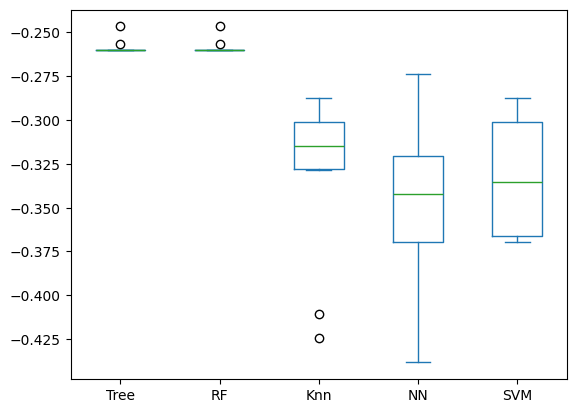

In [ ]:
# Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

In [ ]:
# Desnormalizar para Tree y Random Forest

X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [ ]:
# Modelo final
model_rf.fit(X, Y) #100%

RandomForestClassifier(max_depth=20, max_samples=0.9, min_samples_leaf=10,
                       n_estimators=200)

In [ ]:
# Se guarda el modelo
import pickle
filename = 'modelo-cla.pkl'
variables=X.columns._values
pickle.dump([model_rf,labelencoder,variables,min_max_scaler], open(filename, 'wb'))